Panel: 703,087 x 59
DID sample: 9,503 rows
  HH communities: 11
  LL communities: 2
  Total clusters: 13
  Year-months: 24

Specification               DID Coef   Clust SE    p-value          N
----------------------------------------------------------------------
  Pooled OLS                  -6.047      1.461     0.0000      9,503
  Community FE                -6.047      1.462     0.0000      9,503
  TWFE (Comm + Month)         -6.144      1.365     0.0000      9,503


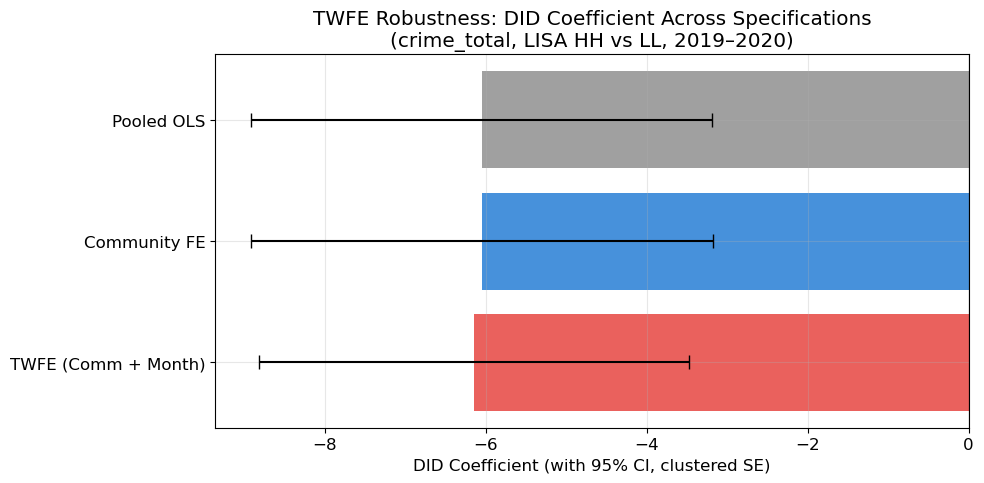


PART 1 SUMMARY
Specification               DID Coef   Clust SE    p-value
----------------------------------------------------------------------
Pooled OLS                    -6.047      1.461     0.0000
Community FE                  -6.047      1.462     0.0000
TWFE (Comm + Month)           -6.144      1.365     0.0000

Key takeaway: The DID estimate of approximately -6 crimes/day is
stable across three specifications with progressively stronger FE
controls. The COVID effect on HH (vs LL) communities is robust to
the choice of fixed-effects structure.


In [2]:
# NB07B: Additional Robustness Checks
# Part 1: TWFE (community + year-month FE). Part 2: Weekend/holiday
# heterogeneity + crime-type forest plot. Part 3: Triangulation of 17 DID estimates across all specifications.
# Note: 13 clusters only; coefficient stability is the main diagnostic.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import warnings
import os

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.figsize': (14, 6), 'font.size': 12,
                     'axes.grid': True, 'grid.alpha': 0.3})

FIGURE_DIR = './figures/nb07b'
os.makedirs(FIGURE_DIR, exist_ok=True)

# %%
panel = pd.read_parquet('./data/panel_ca_daily_v2.parquet')
panel['date'] = pd.to_datetime(panel['date'])
panel['community_area'] = panel['community_area'].astype(str)
print(f"Panel: {panel.shape[0]:,} x {panel.shape[1]}")

# Part 1: Two-Way Fixed Effects (TWFE)
# TWFE adds month-level fixed effects:
# Y_it = α_i + λ_t + β·DID_it + X_it·γ + ε_it
# where λ_t = year-month FE.
# 1.1 Prepare DID sample (identical to NB05)

did_sample = panel[
    (panel['lisa_cluster'].isin(['HH', 'LL'])) &
    (panel['year'].isin([2019, 2020]))
].copy()

did_sample['post'] = (did_sample['date'] >= '2020-03-21').astype(int)
did_sample['treated'] = (did_sample['lisa_cluster'] == 'HH').astype(int)
did_sample['did'] = did_sample['post'] * did_sample['treated']
did_sample['year_month'] = did_sample['date'].dt.to_period('M').astype(str)

n_hh = did_sample[did_sample['treated']==1]['community_area'].nunique()
n_ll = did_sample[did_sample['treated']==0]['community_area'].nunique()
n_months = did_sample['year_month'].nunique()

print(f"DID sample: {len(did_sample):,} rows")
print(f"  HH communities: {n_hh}")
print(f"  LL communities: {n_ll}")
print(f"  Total clusters: {n_hh + n_ll}")
print(f"  Year-months: {n_months}")

# 1.2 Three nested specifications

controls = 'temp_mean + precipitation + is_weekend + is_holiday'

specs = {
    'Pooled OLS':         f'crime_total ~ post + treated + did + {controls}',
    'Community FE':       f'crime_total ~ post + did + {controls} + C(community_area)',
    'TWFE (Comm + Month)':f'crime_total ~ did + {controls} + C(community_area) + C(year_month)',
}

results = {}
print(f"\n{'Specification':<25s} {'DID Coef':>10s} {'Clust SE':>10s} {'p-value':>10s} {'N':>10s}")
print("-" * 70)

for name, formula in specs.items():
    mod = smf.ols(formula, data=did_sample).fit(
        cov_type='cluster',
        cov_kwds={'groups': did_sample['community_area']}
    )
    results[name] = mod
    print(f"  {name:<23s} {mod.params['did']:>+10.3f} "
          f"{mod.bse['did']:>10.3f} {mod.pvalues['did']:>10.4f} "
          f"{int(mod.nobs):>10,}")

# 1.3 Visualize: coefficient stability across specifications

fig, ax = plt.subplots(figsize=(10, 5))

names = list(results.keys())
coefs = [results[n].params['did'] for n in names]
ses   = [results[n].bse['did']   for n in names]
ci_lo = [c - 1.96*s for c, s in zip(coefs, ses)]
ci_hi = [c + 1.96*s for c, s in zip(coefs, ses)]

y_pos = np.arange(len(names))
ax.barh(y_pos, coefs, xerr=[np.array(coefs)-np.array(ci_lo),
                             np.array(ci_hi)-np.array(coefs)],
        color=['#888', '#1976D2', '#E53935'], capsize=5, alpha=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(names)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('DID Coefficient (with 95% CI, clustered SE)')
ax.set_title('TWFE Robustness: DID Coefficient Across Specifications\n'
             '(crime_total, LISA HH vs LL, 2019–2020)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, '01_twfe_specification_comparison.png'),
            dpi=150, bbox_inches='tight')
plt.show()


# 1.5 Interpretation
print("\n" + "="*70)
print("PART 1 SUMMARY")
print("="*70)
print(f"{'Specification':<25s} {'DID Coef':>10s} {'Clust SE':>10s} {'p-value':>10s}")
print("-" * 70)
for name in names:
    m = results[name]
    print(f"{name:<25s} {m.params['did']:>+10.3f} {m.bse['did']:>10.3f} {m.pvalues['did']:>10.4f}")
print("="*70)
print("\nKey takeaway: The DID estimate of approximately -6 crimes/day is")
print("stable across three specifications with progressively stronger FE")
print("controls. The COVID effect on HH (vs LL) communities is robust to")
print("the choice of fixed-effects structure.")

WEEKEND × TREATMENT INTERACTION

Term                            Coef   Clust SE    p-value
----------------------------------------------------------------------
did                           -6.389      1.509     0.0000
did:is_weekend                +1.194      0.297     0.0001

Implied total COVID effect:
  Weekday HH−LL effect:     -6.389
  Weekend HH−LL effect:     -5.195
  Weekend - Weekday diff:   +1.194 (p=0.0001)

HOLIDAY × TREATMENT INTERACTION

Term                            Coef   Clust SE    p-value
----------------------------------------------------------------------
did                           -6.034      1.453     0.0000
did:is_holiday                -0.526      0.620     0.3963

Implied total COVID effect:
  Non-holiday HH−LL effect:   -6.034
  Holiday HH−LL effect:       -6.560
  Holiday - Non-holiday:      -0.526 (p=0.3963)


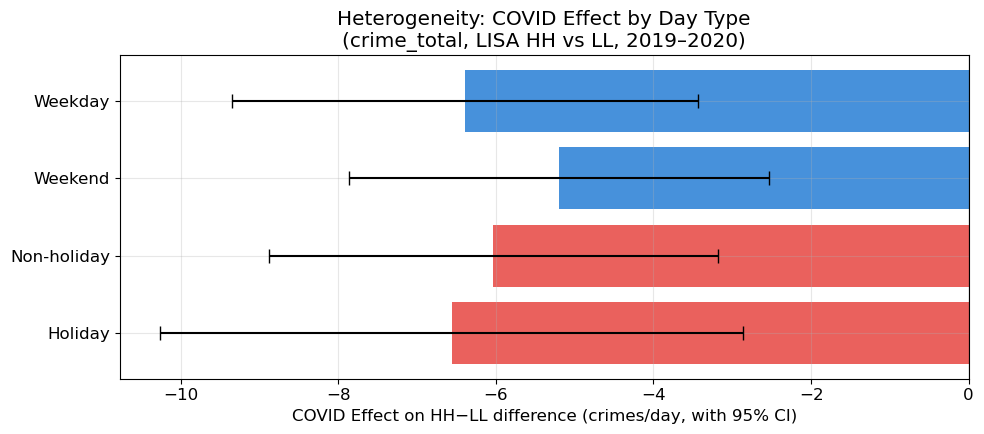


CRIME-TYPE DID ESTIMATES

Crime type                  Coef        SE    p-value   Sig
----------------------------------------------------------------------
Total crime               -6.047     1.462     0.0000   ***
Theft                     -2.722     1.132     0.0162     *
Property crime            -2.628     1.088     0.0157     *
Arrests                   -2.213     0.504     0.0000   ***
Narcotics                 -1.166     0.452     0.0098    **
Violent crime             -0.920     0.296     0.0019    **
Battery                   -0.647     0.165     0.0001   ***
Domestic                  -0.305     0.089     0.0006   ***
Assault                   -0.196     0.077     0.0110     *
Robbery                   -0.068     0.064     0.2916      
Homicide                  +0.012     0.013     0.3761      
Burglary                  +0.059     0.108     0.5832      
Motor vehicle theft       +0.134     0.050     0.0080    **


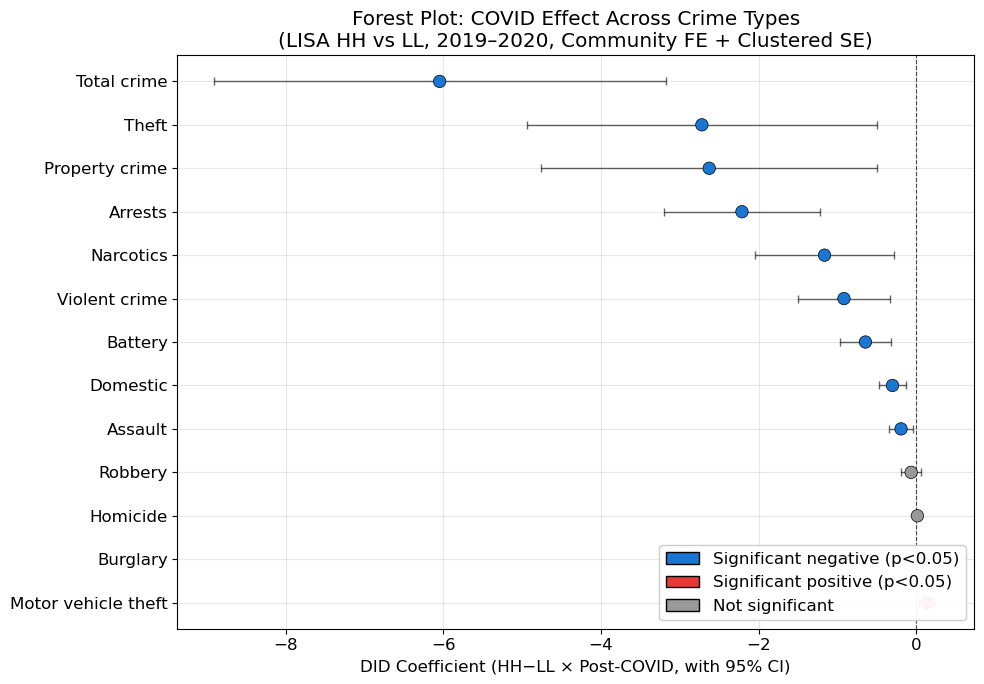


PART 2 SUMMARY
Weekend × DID interaction:   +1.194 (p = 0.0001)
Holiday × DID interaction:   -0.526 (p = 0.3963)

Crime types tested: 13
  Significantly negative (p<0.05): 9
  Significantly positive (p<0.05): 1
  Not significant:                 3


In [3]:
# Part 2: Heterogeneity Extensions
# 2.1 Weekend × Treatment

# Use the same did_sample built in Part 1
ws = did_sample.copy()

# Construct full triple interaction
# We drop is_weekend from controls because it now interacts with did/post
controls_no_weekend = 'temp_mean + precipitation + is_holiday'

formula_weekend = (
    'crime_total ~ post + did + is_weekend '
    '+ post:is_weekend + did:is_weekend '
    f'+ {controls_no_weekend} + C(community_area)'
)

mod_weekend = smf.ols(formula_weekend, data=ws).fit(
    cov_type='cluster',
    cov_kwds={'groups': ws['community_area']}
)

print("="*70)
print("WEEKEND × TREATMENT INTERACTION")
print("="*70)
print(f"\n{'Term':<25s} {'Coef':>10s} {'Clust SE':>10s} {'p-value':>10s}")
print("-" * 70)
key_terms = ['did', 'did:is_weekend']
for term in key_terms:
    if term in mod_weekend.params.index:
        c = mod_weekend.params[term]
        s = mod_weekend.bse[term]
        p = mod_weekend.pvalues[term]
        print(f"{term:<25s} {c:>+10.3f} {s:>10.3f} {p:>10.4f}")

# Interpretation: total effect on weekends = did + did:is_weekend
did_weekday = mod_weekend.params['did']
did_weekend_diff = mod_weekend.params['did:is_weekend']
did_weekend_total = did_weekday + did_weekend_diff
print(f"\nImplied total COVID effect:")
print(f"  Weekday HH−LL effect:   {did_weekday:>+8.3f}")
print(f"  Weekend HH−LL effect:   {did_weekend_total:>+8.3f}")
print(f"  Weekend - Weekday diff: {did_weekend_diff:>+8.3f} (p={mod_weekend.pvalues['did:is_weekend']:.4f})")

# 2.2 Holiday × Treatment

controls_no_holiday = 'temp_mean + precipitation + is_weekend'

formula_holiday = (
    'crime_total ~ post + did + is_holiday '
    '+ post:is_holiday + did:is_holiday '
    f'+ {controls_no_holiday} + C(community_area)'
)

mod_holiday = smf.ols(formula_holiday, data=ws).fit(
    cov_type='cluster',
    cov_kwds={'groups': ws['community_area']}
)

print("\n" + "="*70)
print("HOLIDAY × TREATMENT INTERACTION")
print("="*70)
print(f"\n{'Term':<25s} {'Coef':>10s} {'Clust SE':>10s} {'p-value':>10s}")
print("-" * 70)
for term in ['did', 'did:is_holiday']:
    if term in mod_holiday.params.index:
        c = mod_holiday.params[term]
        s = mod_holiday.bse[term]
        p = mod_holiday.pvalues[term]
        print(f"{term:<25s} {c:>+10.3f} {s:>10.3f} {p:>10.4f}")

did_nonholiday = mod_holiday.params['did']
did_holiday_diff = mod_holiday.params['did:is_holiday']
did_holiday_total = did_nonholiday + did_holiday_diff
print(f"\nImplied total COVID effect:")
print(f"  Non-holiday HH−LL effect: {did_nonholiday:>+8.3f}")
print(f"  Holiday HH−LL effect:     {did_holiday_total:>+8.3f}")
print(f"  Holiday - Non-holiday:    {did_holiday_diff:>+8.3f} (p={mod_holiday.pvalues['did:is_holiday']:.4f})")

# 2.3 Visualize: subgroup effects

fig, ax = plt.subplots(figsize=(10, 4.5))

subgroups = ['Weekday', 'Weekend', 'Non-holiday', 'Holiday']
effects = [did_weekday, did_weekend_total, did_nonholiday, did_holiday_total]
# Approximate SE for total effect (conservative — uses delta method-equivalent from the variance of the linear combination)
# For did + did:is_weekend, var = var(did) + var(int) + 2*cov
def linear_combo_se(model, terms):
    """SE of the sum of two coefficients."""
    cov = model.cov_params()
    v = sum(cov.loc[t, t] for t in terms)
    for i, t1 in enumerate(terms):
        for t2 in terms[i+1:]:
            v += 2 * cov.loc[t1, t2]
    return np.sqrt(v)

se_weekday = mod_weekend.bse['did']
se_weekend = linear_combo_se(mod_weekend, ['did', 'did:is_weekend'])
se_nonhol  = mod_holiday.bse['did']
se_hol     = linear_combo_se(mod_holiday, ['did', 'did:is_holiday'])
ses_subgroup = [se_weekday, se_weekend, se_nonhol, se_hol]

ci_lo = [c - 1.96*s for c, s in zip(effects, ses_subgroup)]
ci_hi = [c + 1.96*s for c, s in zip(effects, ses_subgroup)]

colors = ['#1976D2', '#1976D2', '#E53935', '#E53935']
y_pos = np.arange(len(subgroups))
ax.barh(y_pos, effects, xerr=[np.array(effects)-np.array(ci_lo),
                               np.array(ci_hi)-np.array(effects)],
        color=colors, capsize=5, alpha=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(subgroups)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('COVID Effect on HH−LL difference (crimes/day, with 95% CI)')
ax.set_title('Heterogeneity: COVID Effect by Day Type\n'
             '(crime_total, LISA HH vs LL, 2019–2020)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, '02_heterogeneity_daytype.png'),
            dpi=150, bbox_inches='tight')
plt.show()

# 2.4 Crime-type forest plot
# The 13 crime-type DIDs were already computed in NB07. We re-compute them here for completeness and present them as a polished forest plot suitable for the
# final report and viva slides.

# Identify available crime types in panel
crime_types = [
    ('crime_total',     'Total crime'),
    ('crime_violent',   'Violent crime'),
    ('crime_property',  'Property crime'),
    ('crime_theft',     'Theft'),
    ('crime_battery',   'Battery'),
    ('crime_assault',   'Assault'),
    ('crime_robbery',   'Robbery'),
    ('crime_burglary',  'Burglary'),
    ('crime_homicide',  'Homicide'),
    ('crime_mvt',       'Motor vehicle theft'),
    ('crime_narcotics', 'Narcotics'),
    ('arrest_count',    'Arrests'),
    ('domestic_count',  'Domestic'),
]

ct_results = []
controls_full = 'temp_mean + precipitation + is_weekend + is_holiday'

for col, label in crime_types:
    if col not in ws.columns:
        continue
    formula = f'{col} ~ post + did + {controls_full} + C(community_area)'
    try:
        mod = smf.ols(formula, data=ws).fit(
            cov_type='cluster',
            cov_kwds={'groups': ws['community_area']}
        )
        ct_results.append({
            'crime_type': label,
            'coef': mod.params['did'],
            'se':   mod.bse['did'],
            'p':    mod.pvalues['did'],
            'ci_lo': mod.params['did'] - 1.96 * mod.bse['did'],
            'ci_hi': mod.params['did'] + 1.96 * mod.bse['did'],
        })
    except Exception as e:
        print(f"Skipped {label}: {e}")

ct_df = pd.DataFrame(ct_results)
# Sort by point estimate (most negative effect on top → most reduced by COVID)
ct_df = ct_df.sort_values('coef').reset_index(drop=True)

print("\n" + "="*70)
print("CRIME-TYPE DID ESTIMATES")
print("="*70)
print(f"\n{'Crime type':<22s} {'Coef':>9s} {'SE':>9s} {'p-value':>10s} {'Sig':>5s}")
print("-" * 70)
for _, row in ct_df.iterrows():
    sig = '***' if row['p'] < 0.001 else ('**' if row['p'] < 0.01 else ('*' if row['p'] < 0.05 else ''))
    print(f"{row['crime_type']:<22s} {row['coef']:>+9.3f} {row['se']:>9.3f} "
          f"{row['p']:>10.4f} {sig:>5s}")

# Forest plot
fig, ax = plt.subplots(figsize=(10, 7))

y_pos = np.arange(len(ct_df))
# Color by significance and direction
colors = []
for _, row in ct_df.iterrows():
    if row['p'] >= 0.05:
        colors.append('#999')      # not significant — grey
    elif row['coef'] < 0:
        colors.append('#1976D2')   # significantly negative — blue
    else:
        colors.append('#E53935')   # significantly positive — red

ax.errorbar(ct_df['coef'], y_pos,
            xerr=[ct_df['coef'] - ct_df['ci_lo'], ct_df['ci_hi'] - ct_df['coef']],
            fmt='none', ecolor='black', capsize=3, lw=1, alpha=0.6)
ax.scatter(ct_df['coef'], y_pos, c=colors, s=80, zorder=5, edgecolor='black', lw=0.5)
ax.axvline(0, color='black', lw=0.8, linestyle='--', alpha=0.7)
ax.set_yticks(y_pos)
ax.set_yticklabels(ct_df['crime_type'])
ax.set_xlabel('DID Coefficient (HH−LL × Post-COVID, with 95% CI)')
ax.set_title('Forest Plot: COVID Effect Across Crime Types\n'
             '(LISA HH vs LL, 2019–2020, Community FE + Clustered SE)')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#1976D2', edgecolor='black', label='Significant negative (p<0.05)'),
    Patch(facecolor='#E53935', edgecolor='black', label='Significant positive (p<0.05)'),
    Patch(facecolor='#999',    edgecolor='black', label='Not significant'),
]
ax.legend(handles=legend_elements, loc='lower right', framealpha=0.95)

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, '03_crimetype_forest.png'),
            dpi=150, bbox_inches='tight')
plt.show()

# 2.5 Interpretation

print("\n" + "="*70)
print("PART 2 SUMMARY")
print("="*70)
print(f"Weekend × DID interaction:  {mod_weekend.params['did:is_weekend']:>+7.3f} "
      f"(p = {mod_weekend.pvalues['did:is_weekend']:.4f})")
print(f"Holiday × DID interaction:  {mod_holiday.params['did:is_holiday']:>+7.3f} "
      f"(p = {mod_holiday.pvalues['did:is_holiday']:.4f})")
n_sig_neg = ((ct_df['p'] < 0.05) & (ct_df['coef'] < 0)).sum()
n_sig_pos = ((ct_df['p'] < 0.05) & (ct_df['coef'] > 0)).sum()
n_null    = (ct_df['p'] >= 0.05).sum()
print(f"\nCrime types tested: {len(ct_df)}")
print(f"  Significantly negative (p<0.05): {n_sig_neg}")
print(f"  Significantly positive (p<0.05): {n_sig_pos}")
print(f"  Not significant:                 {n_null}")
print("="*70)

MASTER TABLE: ALL DID ESTIMATES (NB05 + NB07B)

Group                          Label                       Coef       SE        p
----------------------------------------------------------------------------------
NB05 main                      DID (Community FE)        -6.047    1.462   0.0000
Part 1: FE specs               Pooled OLS                -6.047    1.461   0.0000
                               Community FE              -6.047    1.462   0.0000
                               TWFE (Comm + Month)       -6.144    1.365   0.0000
Part 2: Day type               Weekday effect            -6.389    1.509   0.0000
                               Weekend effect            -5.195    1.360      —  
                               Non-holiday effect        -6.034    1.453   0.0000
                               Holiday effect            -6.560    1.888      —  
Part 2: Crime types (sig neg)  Total crime               -6.047    1.462   0.0000
                               Theft             

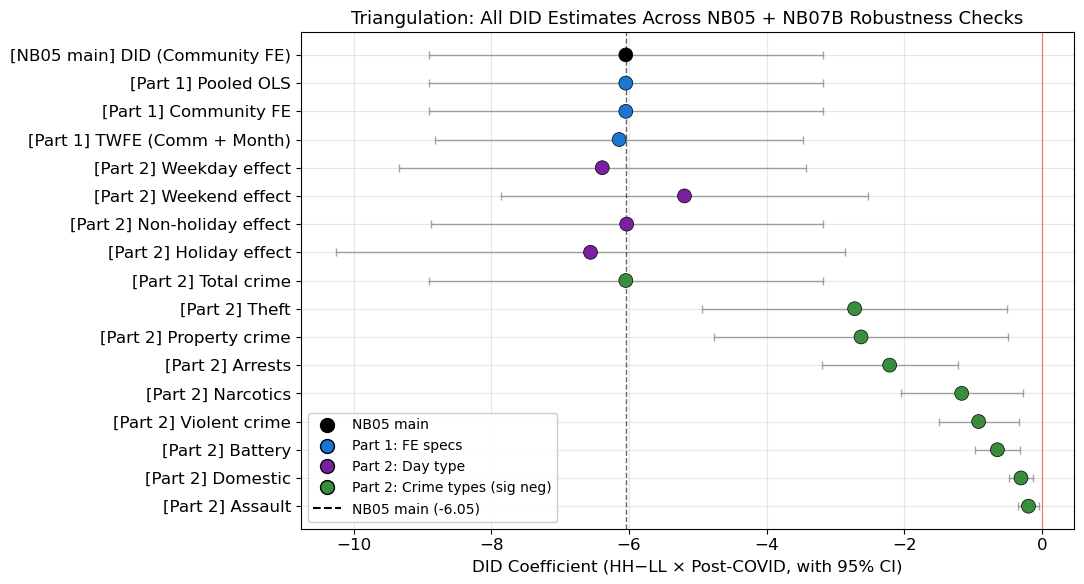


PART 3 TRIANGULATION SUMMARY

Total estimates collected:       17
  Pointing same direction (neg): 17  (100%)
  Pointing opposite (pos):        0

NB05 main estimate:              -6.047
Coefficient range across all:    [-6.560, -0.196]
Estimates within ±2 SE of NB05:  9/17

Master table saved to: ./figures/nb07b/master_did_table.csv


In [4]:
# Part 3: Triangulation Summary

# 3.1 Build master table
master_records = []

# --- NB05 main result (re-run here for self-containedness) ---
nb05_formula = (
    'crime_total ~ post + did + temp_mean + precipitation '
    '+ is_weekend + is_holiday + C(community_area)'
)
mod_nb05 = smf.ols(nb05_formula, data=did_sample).fit(
    cov_type='cluster',
    cov_kwds={'groups': did_sample['community_area']}
)
master_records.append({
    'group':  'NB05 main',
    'label':  'DID (Community FE)',
    'coef':   mod_nb05.params['did'],
    'se':     mod_nb05.bse['did'],
    'p':      mod_nb05.pvalues['did'],
})

# NB07B Part 1: TWFE specifications
for name in ['Pooled OLS', 'Community FE', 'TWFE (Comm + Month)']:
    m = results[name]
    master_records.append({
        'group':  'Part 1: FE specs',
        'label':  name,
        'coef':   m.params['did'],
        'se':     m.bse['did'],
        'p':      m.pvalues['did'],
    })

# NB07B Part 2: heterogeneity by day type
master_records.append({
    'group':  'Part 2: Day type',
    'label':  'Weekday effect',
    'coef':   did_weekday,
    'se':     se_weekday,
    'p':      mod_weekend.pvalues['did'],
})
master_records.append({
    'group':  'Part 2: Day type',
    'label':  'Weekend effect',
    'coef':   did_weekend_total,
    'se':     se_weekend,
    'p':      np.nan,  # implied total — main test is on the interaction term
})
master_records.append({
    'group':  'Part 2: Day type',
    'label':  'Non-holiday effect',
    'coef':   did_nonholiday,
    'se':     se_nonhol,
    'p':      mod_holiday.pvalues['did'],
})
master_records.append({
    'group':  'Part 2: Day type',
    'label':  'Holiday effect',
    'coef':   did_holiday_total,
    'se':     se_hol,
    'p':      np.nan,
})

# NB07B Part 2: crime types (those significant at p<0.05)
sig_neg = ct_df[(ct_df['p'] < 0.05) & (ct_df['coef'] < 0)].copy()
for _, row in sig_neg.iterrows():
    master_records.append({
        'group':  'Part 2: Crime types (sig neg)',
        'label':  row['crime_type'],
        'coef':   row['coef'],
        'se':     row['se'],
        'p':      row['p'],
    })

master_df = pd.DataFrame(master_records)

# Pretty print
print("="*82)
print("MASTER TABLE: ALL DID ESTIMATES (NB05 + NB07B)")
print("="*82)
print(f"\n{'Group':<30s} {'Label':<22s} {'Coef':>9s} {'SE':>8s} {'p':>8s}")
print("-" * 82)
last_group = None
for _, row in master_df.iterrows():
    group_disp = row['group'] if row['group'] != last_group else ''
    last_group = row['group']
    p_disp = f"{row['p']:.4f}" if not np.isnan(row['p']) else '   —  '
    print(f"{group_disp:<30s} {row['label']:<22s} "
          f"{row['coef']:>+9.3f} {row['se']:>8.3f} {p_disp:>8s}")
print("="*82)

# 3.2 Triangulation forest plot

fig, ax = plt.subplots(figsize=(11, max(6, 0.35*len(master_df))))

# Order: keep the order of insertion (group by group)
y_pos = np.arange(len(master_df))[::-1]  # top of plot = first row

# Color by group
group_colors = {
    'NB05 main':                     '#000000',
    'Part 1: FE specs':              '#1976D2',
    'Part 2: Day type':              '#7B1FA2',
    'Part 2: Crime types (sig neg)': '#388E3C',
}
colors = [group_colors[g] for g in master_df['group']]

ci_lo = master_df['coef'] - 1.96 * master_df['se']
ci_hi = master_df['coef'] + 1.96 * master_df['se']

ax.errorbar(master_df['coef'], y_pos,
            xerr=[master_df['coef']-ci_lo, ci_hi-master_df['coef']],
            fmt='none', ecolor='gray', capsize=3, lw=1, alpha=0.7)
ax.scatter(master_df['coef'], y_pos, c=colors, s=100, zorder=5,
           edgecolor='black', lw=0.5)

# Reference line at NB05 main estimate
nb05_main = master_df.iloc[0]['coef']
ax.axvline(nb05_main, color='black', lw=1, linestyle='--', alpha=0.6,
           label=f'NB05 main estimate ({nb05_main:.2f})')
ax.axvline(0, color='red', lw=0.8, alpha=0.5)

# Labels
y_labels = [f"[{g.split(':')[0]}] {l}" for g, l in zip(master_df['group'], master_df['label'])]
ax.set_yticks(y_pos)
ax.set_yticklabels(y_labels)
ax.set_xlabel('DID Coefficient (HH−LL × Post-COVID, with 95% CI)')
ax.set_title('Triangulation: All DID Estimates Across NB05 + NB07B Robustness Checks',
             fontsize=13)

# Legend for groups
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor=col,
           markeredgecolor='black', markersize=10, label=grp)
    for grp, col in group_colors.items()
]
legend_elements.append(
    Line2D([0],[0], color='black', linestyle='--', label=f'NB05 main ({nb05_main:.2f})')
)
ax.legend(handles=legend_elements, loc='lower left', framealpha=0.95, fontsize=10)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, '04_triangulation_forest.png'),
            dpi=150, bbox_inches='tight')
plt.show()

# 3.3 Numeric synthesis

n_total = len(master_df)
n_neg = (master_df['coef'] < 0).sum()
n_pos = (master_df['coef'] > 0).sum()

# How many estimates fall within ±2 SE of NB05 main?
within_band = (
    (master_df['coef'] >= nb05_main - 2*master_df.iloc[0]['se']) &
    (master_df['coef'] <= nb05_main + 2*master_df.iloc[0]['se'])
).sum()

print("\n" + "="*70)
print("PART 3 TRIANGULATION SUMMARY")
print("="*70)
print(f"\nTotal estimates collected:       {n_total}")
print(f"  Pointing same direction (neg): {n_neg}  ({n_neg/n_total*100:.0f}%)")
print(f"  Pointing opposite (pos):        {n_pos}")
print(f"\nNB05 main estimate:              {nb05_main:+.3f}")
print(f"Coefficient range across all:    [{master_df['coef'].min():+.3f}, "
      f"{master_df['coef'].max():+.3f}]")
print(f"Estimates within ±2 SE of NB05:  {within_band}/{n_total}")
print("="*70)

# 3.4 Narrative summary
# Save the master table for reference / inclusion in the report
master_df.to_csv(os.path.join(FIGURE_DIR, 'master_did_table.csv'), index=False)
print(f"\nMaster table saved to: {FIGURE_DIR}/master_did_table.csv")